# California Housing - Data Preparation

In this notebook we:
- Load raw data
- Explore dataset structure
- Perform feature engineering
- Handle categorical variables
- Split dataset
- Scale features

Goal: Create a clean dataset for modeling and experiments.

### Libraries

In [31]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import importlib
import src.data_utils as du

importlib.reload(du)

<module 'src.data_utils' from 'e:\\Deep_learning\\Projects\\California-Housing-Comprehensive-Analysis\\src\\data_utils.py'>

### Extract Data

In [32]:
du.extract_data('../dataset/data.zip', '../dataset/')

### Load dataset

In [33]:
df = du.load_csv('../dataset/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Data Overview

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [35]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [36]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### Geographic Visualization

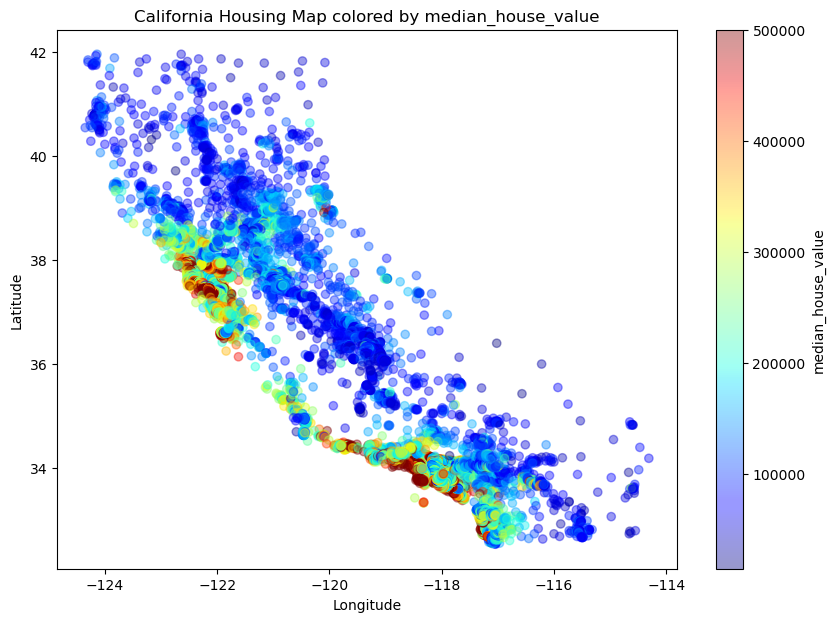

In [37]:
# based on median_house_value
du.plot_housing_scatter(df, "median_house_value")

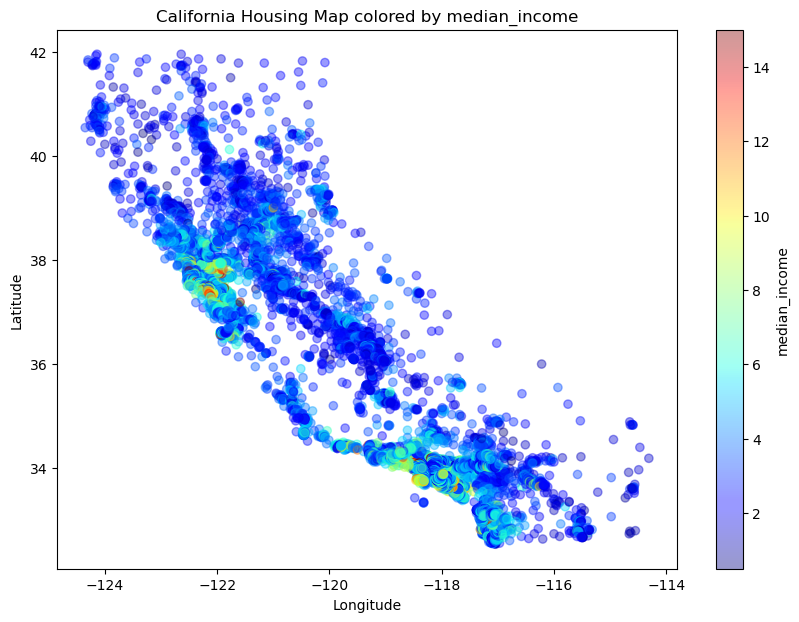

In [38]:
# based on median_income
du.plot_housing_scatter(df, "median_income")

### Distribution and Outlier Validation

#### 1. Population

##### 1.1. Histogram

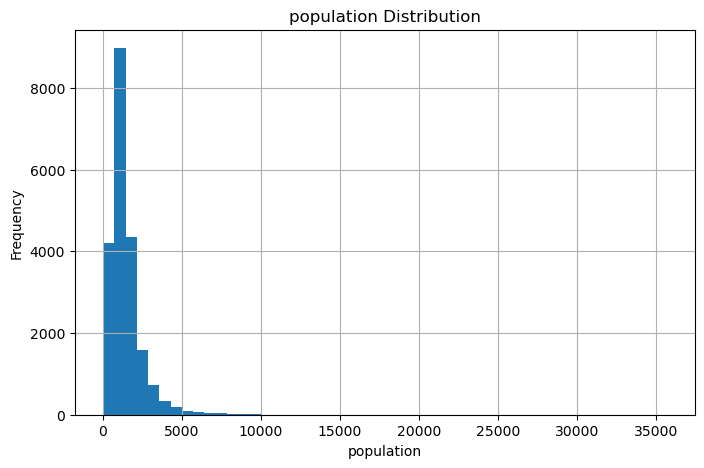

In [39]:
du.plot_histogram(df, column="population")

##### 1.2. Boxplot

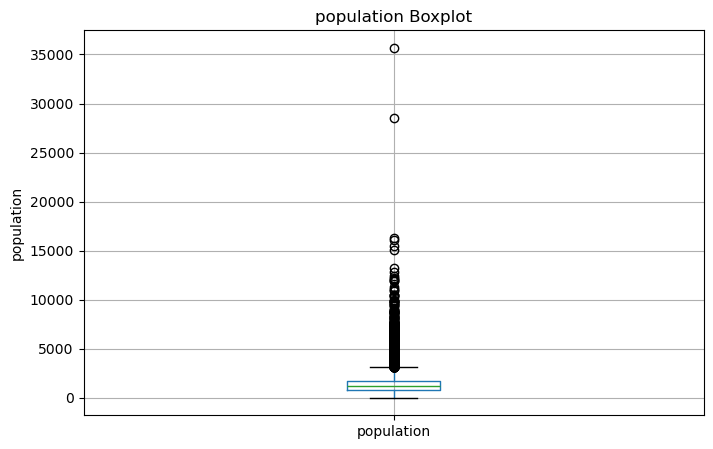

In [40]:
du.plot_boxplot(df, "population")

##### 1.3. IQR

In [41]:
Q1 = df["population"].quantile(0.25)
Q3 = df["population"].quantile(0.75)
IQR = Q3 - Q1
print("Upper Bound", Q3 + 1.5 * IQR)

outliers = df[df["population"] > Q3 + 1.5 * IQR]
outliers

Upper Bound 3132.0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
95,-122.26,37.80,36.0,5329.0,2477.0,3469.0,2323.0,2.0096,130000.0,NEAR BAY
185,-122.23,37.79,43.0,5963.0,1344.0,4367.0,1231.0,2.1917,112800.0,NEAR BAY
283,-122.16,37.79,22.0,12842.0,2048.0,4985.0,1967.0,5.9849,371000.0,NEAR BAY
460,-122.26,37.87,52.0,1087.0,371.0,3337.0,350.0,1.4012,175000.0,NEAR BAY
485,-122.26,37.86,35.0,5161.0,1744.0,3276.0,1742.0,1.6307,253600.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20543,-121.74,38.55,33.0,6861.0,1820.0,3717.0,1767.0,1.7311,182600.0,INLAND
20544,-121.76,38.55,23.0,8800.0,1857.0,6330.0,1832.0,2.0650,219400.0,INLAND
20563,-121.75,38.67,9.0,12139.0,2640.0,6837.0,2358.0,3.1250,132500.0,INLAND
20604,-121.54,39.12,17.0,4251.0,899.0,3265.0,934.0,2.3496,65000.0,INLAND


#### 2. Total Rooms

##### 2.1. Histogram

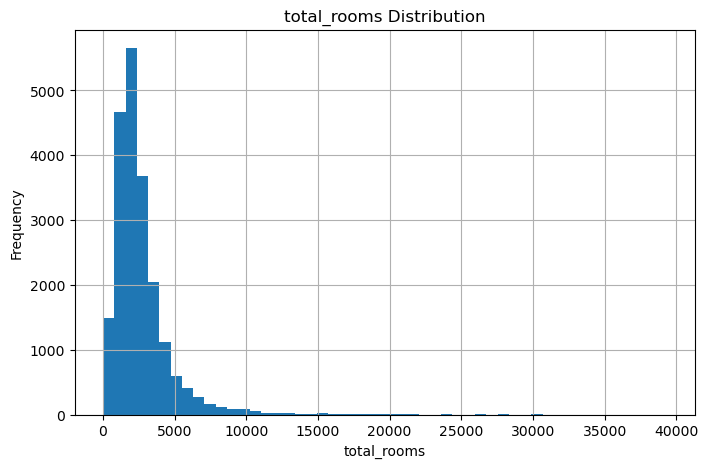

In [42]:
du.plot_histogram(df, "total_rooms")

#### 2.2 Boxplot

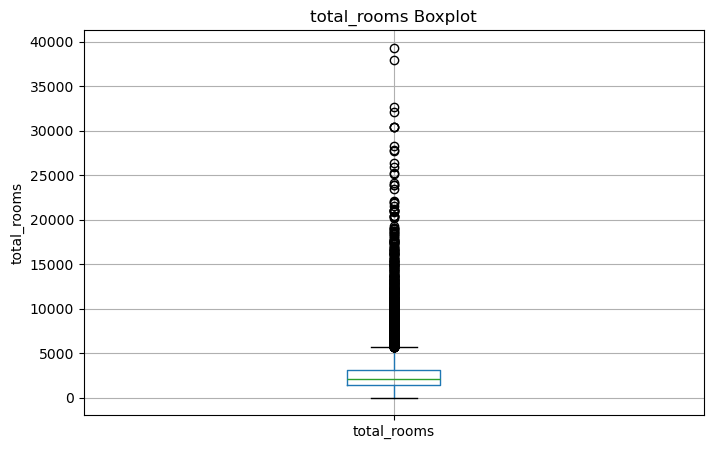

In [43]:
du.plot_boxplot(df, "total_rooms")

#### 3. Median Income

##### 3.1. Histogram

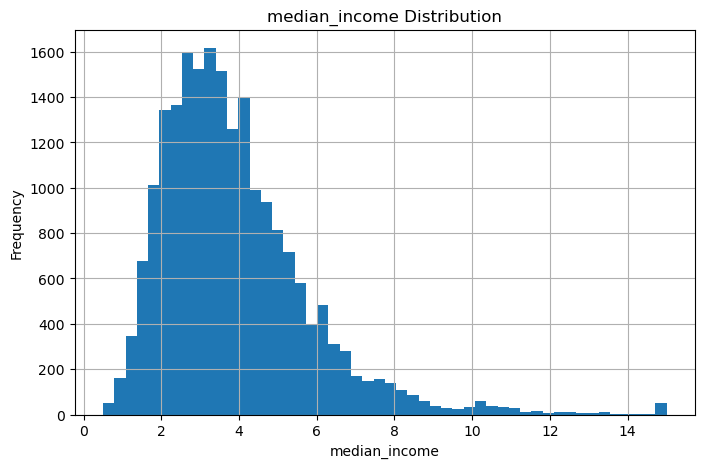

In [44]:
du.plot_histogram(df, "median_income")

##### 3.2. Boxplot

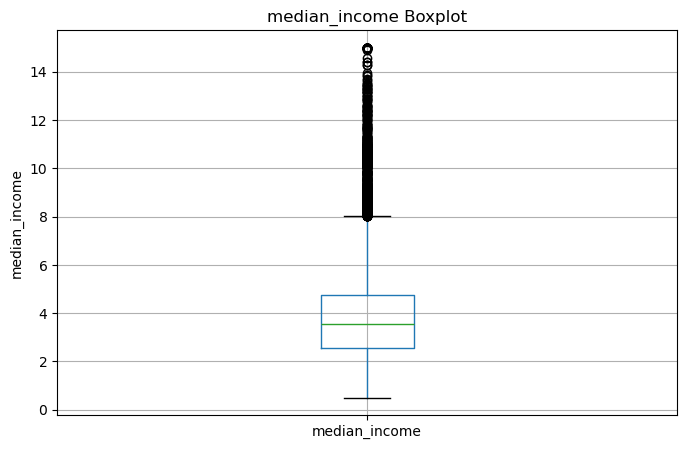

In [45]:
du.plot_boxplot(df, "median_income")

#### Other Features (Histogram & Boxplot)

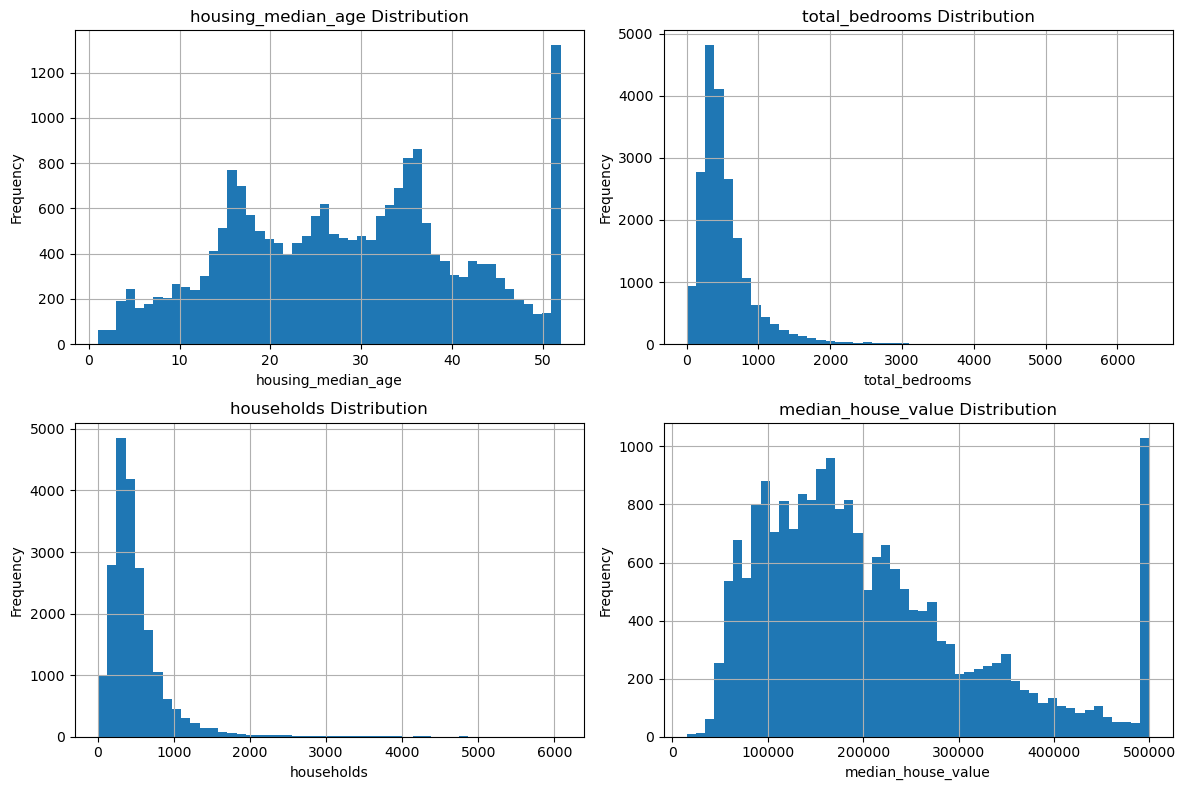

In [46]:
du.plot_multi_histograms(df, ["housing_median_age", "total_bedrooms", "households", "median_house_value"])

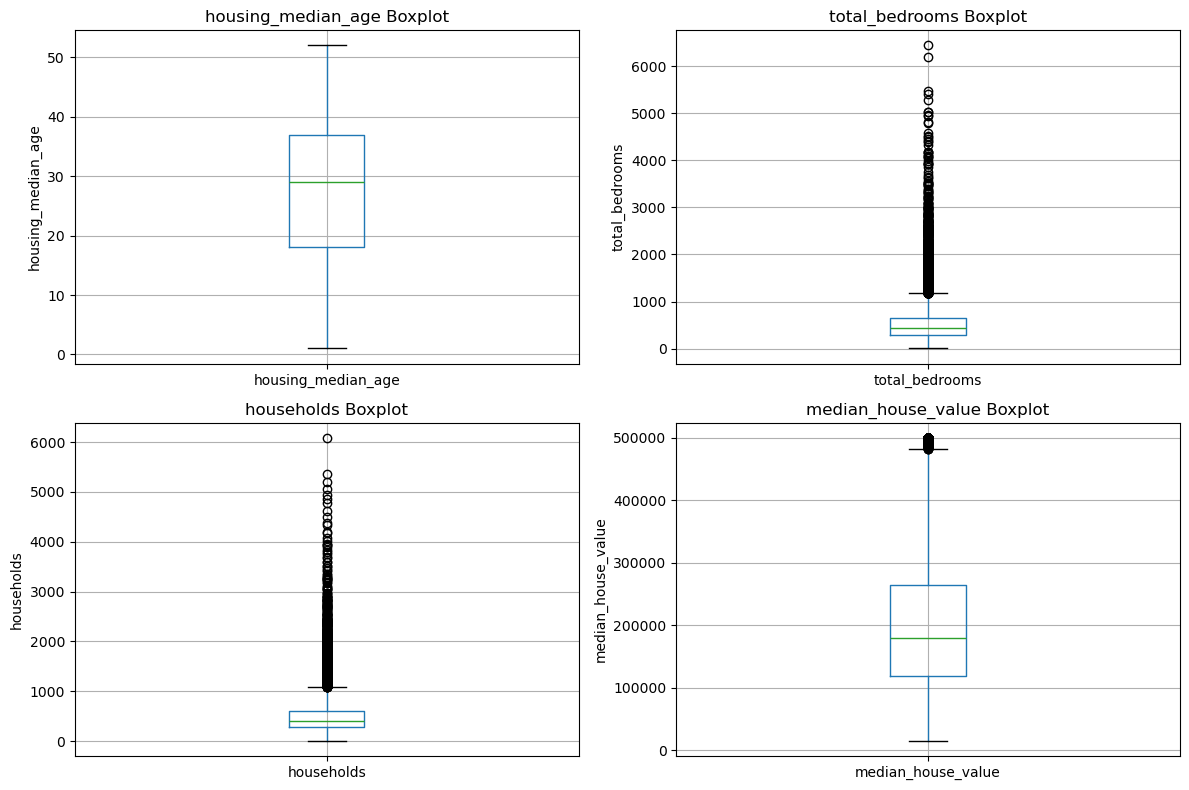

In [47]:
du.plot_multi_boxplots(df, ["housing_median_age", "total_bedrooms", "households", "median_house_value"])